### Learning Objectives:
1. Understand why ensembles outperform single models
2. Master bagging (Random Forest) vs boosting (Gradient Boosting)
3. Interpret models using feature importance
4. Tune XGBoost with cross-validation like a pro

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(f'Dataset: {X.shape}')

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42)
print(f'Train:{len(X_train)} Val:{len(X_val)} Test:{len(X_test)}')

Dataset: (569, 30)
Train:397 Val:86 Test:86


In [3]:
#Single Decision Tree -- Train Unlimited Tree

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [4]:
train_acc = accuracy_score(y_train,tree.predict(X_train))
val_acc = accuracy_score(y_val,tree.predict(X_val))

print(f'Train Acc: {train_acc:.4f}')
print(f'Val Acc: {val_acc:.4f}')
print(f'Gap: {train_acc - val_acc:.4f} (OVERFITTING!)')
print(f'Depth: {tree.get_depth()}')

Train Acc: 1.0000
Val Acc: 0.9070
Gap: 0.0930 (OVERFITTING!)
Depth: 7


In [5]:
#test Depths 1-20

depths = range(1,21)
train_scores = []
val_scores = []

for d in depths:
  t = DecisionTreeClassifier(max_depth=d,random_state=42).fit(X_train,y_train)
  train_scores.append(accuracy_score(y_train,t.predict(X_train)))
  val_scores.append(accuracy_score(y_val,t.predict(X_val)))

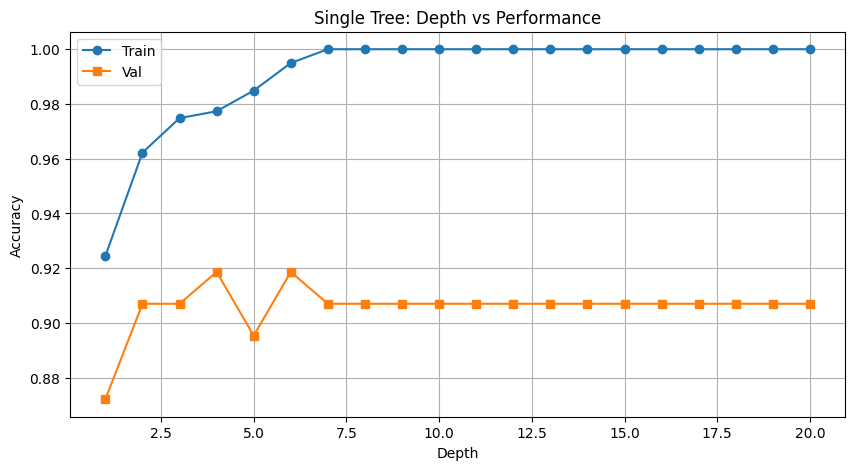

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, 'o-', label='Train')
plt.plot(depths, val_scores, 's-', label='Val')
plt.xlabel('Depth'); plt.ylabel('Accuracy')
plt.title('Single Tree: Depth vs Performance')
plt.legend(); plt.grid(); plt.show()

In [7]:
#Train Random Forest
rf = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)
rf.fit(X_train,y_train)

#accuracy check
rf_val_acc = accuracy_score(y_val,rf.predict(X_val))

print(f'Random Forest Val Acc: {rf_val_acc:.4f}')
print(f'Single Tree Val Acc: {val_acc:.4f}')
print(f'Improvement: {rf_val_acc - val_acc:.4f} (+{((rf_val_acc-val_acc)/val_acc*100):.1f}%)')

Random Forest Val Acc: 0.9419
Single Tree Val Acc: 0.9070
Improvement: 0.0349 (+3.8%)


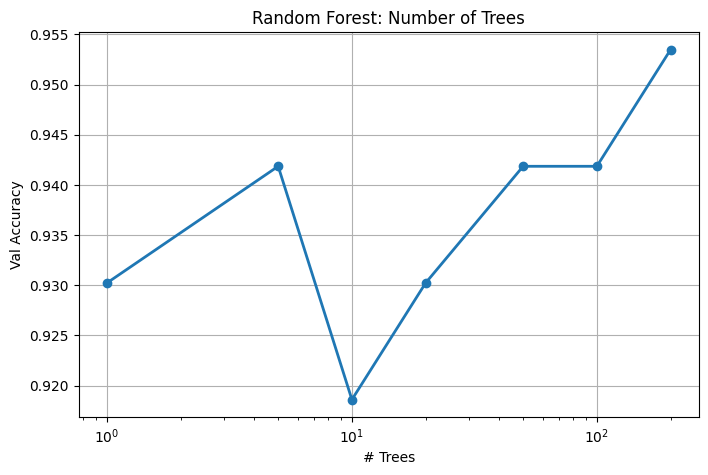

In [8]:
n_trees = [1,5,10,20,50,100,200]

val_accs = []

for n in n_trees:
  rf_temp = RandomForestClassifier(n_estimators=n,random_state=42,n_jobs=-1).fit(X_train,y_train)
  val_accs.append(accuracy_score(y_val,rf_temp.predict(X_val)))

plt.figure(figsize=(8, 5))
plt.plot(n_trees, val_accs, 'o-', linewidth=2)
plt.xlabel('# Trees'); plt.ylabel('Val Accuracy')
plt.title('Random Forest: Number of Trees')
plt.xscale('log'); plt.grid(); plt.show()

In [9]:
#Boosting -- Adaboost , XGBoosting
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [10]:
xgb_val_acc = accuracy_score(y_val, xgb_model.predict(X_val))
xgb_test_acc = accuracy_score(y_test, xgb_model.predict(X_test))

print(f'XGBoost Val Acc: {xgb_val_acc:.4f}')
print(f'XGBoost Test Acc: {xgb_test_acc:.4f}')

XGBoost Val Acc: 0.9302
XGBoost Test Acc: 0.9419


In [11]:
import xgboost as xgb
from sklearn.metrics import accuracy_score

# Early stopping
xgb_early = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    early_stopping_rounds=20
)

In [12]:
xgb_early.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f'Best iteration: {xgb_early.best_iteration}')
print(f'Best val acc: {accuracy_score(y_val, xgb_early.predict(X_val)):.4f}')

Best iteration: 187
Best val acc: 0.9419


In [13]:
# Top Feature selection in XGBoost and Random Tree

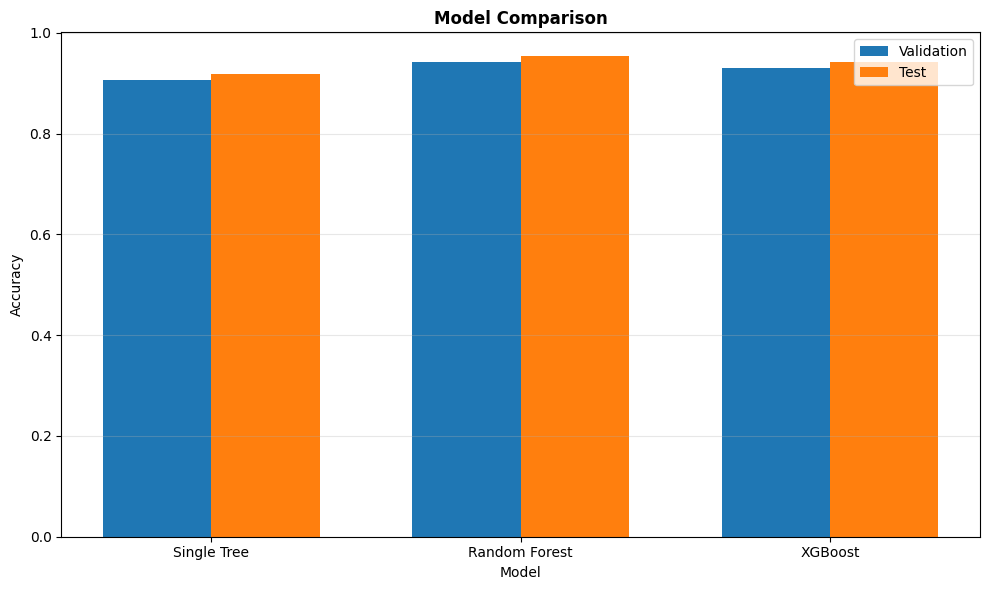


Final Results:
Single Tree     Val:0.9070 Test:0.9186
Random Forest   Val:0.9419 Test:0.9535
XGBoost         Val:0.9302 Test:0.9419


In [14]:
#lets compare all models -- decision tree, random forest,XGBoost

# Compare all models
models = ['Single Tree', 'Random Forest', 'XGBoost']
val_accuracies = [val_acc, rf_val_acc, xgb_val_acc]
test_accuracies = [
    accuracy_score(y_test, tree.predict(X_test)),
    accuracy_score(y_test, rf.predict(X_test)),
    xgb_test_acc
]

x = range(len(models))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - width/2 for i in x], val_accuracies, width, label='Validation')
plt.bar([i + width/2 for i in x], test_accuracies, width, label='Test')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Comparison', fontweight='bold')
plt.xticks(x, models)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nFinal Results:')
for i, model in enumerate(models):
    print(f'{model:15} Val:{val_accuracies[i]:.4f} Test:{test_accuracies[i]:.4f}')